In [ ]:
!pip install lime tmu optuna shap catboost hmmlearn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 29.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath = "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank.py"

with open(filepath, "r") as f:
    content = f.read()

with open(filepath, "w") as f:
    f.write(content.replace("np.uint32(~0)", "np.iinfo(np.uint32).max"))

print("Done")

Done


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
import lime
import lime.lime_tabular
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import KBinsDiscretizer
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import pandas as pd
from tmu.models.regression.vanilla_regressor import TMRegressor
from sklearn import linear_model
import math
from hmmlearn.hmm import GaussianHMM
import time
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/GDP_dataset.csv", parse_dates=["date"])


In [ ]:
df.head()

,date,b30ret,b20ret,b10ret,b7ret,b5ret,b2ret,b1ret,t90ret,t30ret,...,trade_balance,unrate,usd_index,labor_force_women,health_services_emp,homeownership_rate,working_age_pop,migration_fear_idx,labor_force_part,labor_force_men
0,1990-03-31,-0.051113,-0.044353,-0.028089,-0.016606,-0.009294,0.006020,0.016363,0.019578,0.018159,...,-6.213689e+09,5.300000,93.130000,57.6,10872,64.1,159473000,89.928741,66.7,76.6
1,1990-06-30,0.043260,0.043723,0.032971,0.033665,0.033669,0.028198,0.027166,0.021064,0.019253,...,-6.006719e+09,5.333333,92.400000,57.4,11011,63.9,159718600,84.918389,66.4,76.3
2,1990-09-30,-0.036085,-0.023717,-0.005174,0.009938,0.018183,0.023583,0.023220,0.020535,0.018960,...,-9.750953e+09,5.700000,86.576667,57.6,11137,63.9,160222900,96.256257,66.4,76.1
3,1990-12-31,0.099014,0.090041,0.070046,0.058227,0.052214,0.033800,0.027561,0.020656,0.018309,...,-6.282846e+09,6.133333,83.093333,57.3,11271,64.0,160678700,85.235934,66.4,76.3
4,1991-03-31,0.017541,0.018016,0.020850,0.020248,0.016692,0.019653,0.023355,0.016655,0.013858,...,-1.947669e+09,6.600000,86.033333,57.3,11427,64.0,160882600,99.320696,66.3,76.1


In [ ]:
df.shape

(140, 31)

In [ ]:
#default params
def get_model(model_name):
    models = {
        'RF':       RandomForestRegressor(
                        n_estimators=500, max_depth=5,
                        min_samples_leaf=3, random_state=42),
        'GB':       GradientBoostingRegressor(
                        n_estimators=300, learning_rate=0.05,
                        max_depth=3, min_samples_leaf=3,
                        subsample=0.8, random_state=42),
        'XGB':      XGBRegressor(
                        n_estimators=500, learning_rate=0.03,
                        max_depth=3, subsample=0.7,
                        colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=1.0, random_state=42,
                        objective='reg:squarederror'),
        'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
        'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
        'bayes':    BayesianRidge(max_iter=500),
        'catboost': CatBoostRegressor(
                        iterations=500, learning_rate=0.03, depth=4,
                        l2_leaf_reg=5.0, random_state=42, verbose=0)
    }
    return models[model_name]

In [ ]:
PARAM_GRIDS = {
    'RF': {
        'model__n_estimators':      [300, 500],
        'model__max_depth':         [3, 5, None],
        'model__min_samples_leaf':  [3, 5, 8],
        'model__min_samples_split': [5, 10],
        'model__max_features':      ['sqrt', 0.5],
    },
    'GB': {
        'model__n_estimators':     [200, 300],
        'model__learning_rate':    [0.01, 0.03, 0.05],
        'model__max_depth':        [2, 3],
        'model__subsample':        [0.6, 0.7],
        'model__min_samples_leaf': [3, 5],
    },
    'XGB': {
        'model__n_estimators':     [300, 500],
        'model__learning_rate':    [0.01, 0.03],
        'model__max_depth':        [2, 3],
        'model__subsample':        [0.6, 0.7],
        'model__colsample_bytree': [0.6, 0.7],
        'model__reg_alpha':        [0.1, 0.5, 1.0],
        'model__reg_lambda':       [1.0, 2.0],
        'model__min_child_weight': [3, 5],
    },
    'KNN': {
        'model__n_neighbors': [5, 7, 10, 15],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan'],
        'model__leaf_size':   [20, 30],
    },
    'SVR': {
        'model__C':       [1.0, 10.0, 50.0],
        'model__epsilon': [0.001, 0.01, 0.05],
        'model__gamma':   ['scale', 'auto'],
        'model__kernel':  ['rbf', 'linear'],
    },
    'bayes': {
        'model__alpha_1':  [1e-7, 1e-6, 1e-5],
        'model__alpha_2':  [1e-7, 1e-6, 1e-5],
        'model__lambda_1': [1e-7, 1e-6, 1e-5],
        'model__lambda_2': [1e-7, 1e-6, 1e-5],
        'model__max_iter': [300, 500, 1000],
    },
    'catboost': {
        'model__iterations':    [300, 500],
        'model__learning_rate': [0.01, 0.03],
        'model__depth':         [3, 4, 5],
        'model__l2_leaf_reg':   [3.0, 5.0, 10.0],
        'model__subsample':     [0.6, 0.7],
    },
}


BASE_MODELS = {
    'RF':       RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB':       GradientBoostingRegressor(random_state=42),
    'XGB':      XGBRegressor(random_state=42, objective='reg:squarederror',
                             tree_method='hist', verbosity=0),
    'KNN':      KNeighborsRegressor(),
    'SVR':      SVR(),
    'bayes':    BayesianRidge(),
    'catboost': CatBoostRegressor(random_state=42, verbose=0),
}

In [ ]:
def tune_model(model_name, pre_steps, X_train, y_train,
               n_iter=30, cv_splits=5):
    steps  = pre_steps + [('model', BASE_MODELS[model_name])]
    pipe   = Pipeline(steps)
    tscv   = TimeSeriesSplit(n_splits=cv_splits)
    search = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_GRIDS[model_name],
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'r2',
        random_state       = 42,
        n_jobs             = -1,
        refit              = True
    )
    search.fit(X_train, y_train)
    print(f"  Best CV R²:  {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_


In [ ]:
def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)


In [ ]:
def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df


In [ ]:
def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)


In [ ]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()


In [ ]:

def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data        = X_train,
        feature_names        = feature_names,
        mode                 = 'regression',
        discretize_continuous= True,
        random_state         = 42
    )

    all_weights = []
    for i in range(len(X_test)):
        exp          = explainer.explain_instance(
            X_test[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 500
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':     feature_names,
        'importance':  lime_df.abs().mean().values,
        'mean_effect': lime_df.mean().values,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name})\nBlue=increases GDP, Red=decreases GDP")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime


In [ ]:

def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names, model_name,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        plot_macro_bar(fi_standard, f"Standard Importance — All Macro\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


In [ ]:

def run_arima(y_train, y_test, test_dates, X_train=None, X_test=None, use_macro=False):
    if X_train is not None:
        lag_cols = [c for c in X_train.columns if c.endswith('_lag1')]
        X_train = X_train[lag_cols] if len(lag_cols) else None
        X_test  = X_test[lag_cols]  if len(lag_cols) else None

    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 4]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 4),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue
    start = time.time()
    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    end = time.time()
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)
    results = pd.DataFrame({
        "date":          test_dates.values,
        "gdp_growth":    y_test.values,
        "predicted_gdp": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best order AIC: {best_aic:.2f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['gdp_growth'] - row['predicted_gdp'])
        print(f"{str(row['date'])[:10]:<15} {row['gdp_growth']:>12.2f} {row['predicted_gdp']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.4f}")
    print(f"{'MAE:':>45}  {mae:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["gdp_growth"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("GDP")
    ax.set_title(f"GDP Prediction — ARIMA\n(R²={r2:.3f}  RMSE={rmse:.4f}  MAE={mae} MAPE={mape:.1f}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, mae, rmse, mape, r2


In [ ]:
from sklearn.decomposition import PCA

def build_pca_step(X_train, n_features, print_variance=False):
    n_samples, n_raw = X_train.shape
    n_components = min(n_features, n_samples, n_raw)

    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_train)

    if print_variance:
        cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
        print(f"\n  PCA: kept {n_components} components from {n_raw} features")
        print(f"  {'PC':<6} {'Var %':>8} {'Cumul %':>10}")
        print(f"  {'-'*26}")
        for i, (ev, cv) in enumerate(
                zip(pca.explained_variance_ratio_ * 100, cum_var)):
            print(f"  PC{i+1:<4} {ev:>8.2f} {cv:>10.2f}")
        print(f"  → {cum_var[-1]:.1f}% variance retained")

    return pca, n_components

In [ ]:
def _shap_guided_binarise(X_train, X_test, model, min_bins=5, max_bins=20):
    explainer   = shap.Explainer(model, X_train)
    shap_values = explainer(X_train).values
    mean_abs    = np.abs(shap_values).mean(axis=0)

    imp_min, imp_max = mean_abs.min(), mean_abs.max()
    if imp_max - imp_min < 1e-9:
        norm = np.ones_like(mean_abs)
    else:
        norm = (mean_abs - imp_min) / (imp_max - imp_min)

    n_bins_per_feat = np.round(
        min_bins + norm * (max_bins - min_bins)
    ).astype(int)

    print(f"\n  SHAP-guided bins — min:{n_bins_per_feat.min()} "
          f"max:{n_bins_per_feat.max()} "
          f"mean:{n_bins_per_feat.mean():.1f}")

    # Binarise each feature independently
    tr_cols, te_cols = [], []
    for j, nb in enumerate(n_bins_per_feat):
        binner = KBinsDiscretizer(n_bins=nb, encode='ordinal', strategy='quantile')
        tr_cols.append(binner.fit_transform(X_train[:, [j]]))
        te_cols.append(binner.transform(X_test[:, [j]]))

    X_tr_bits = np.hstack(tr_cols).astype(np.uint32)
    X_te_bits = np.hstack(te_cols).astype(np.uint32)
    return X_tr_bits, X_te_bits, n_bins_per_feat

### regime based TM models

In [ ]:
def fit_regime_hmm(df, n_regimes=2, regime_features=None):
    if regime_features is None:
        regime_features = [c for c in ["nfci", "fedfunds", "unrate", "gdp_lag1"]
                           if c in df.columns]

    if len(regime_features) == 0:
        raise ValueError("No regime features found in DataFrame.")

    X_reg = df[regime_features].ffill().bfill().values
    regime_scaler = StandardScaler()
    X_reg_sc      = regime_scaler.fit_transform(X_reg)

    hmm = GaussianHMM(
        n_components  = n_regimes,
        covariance_type = "full",
        n_iter        = 200,
        random_state  = 42
    )
    hmm.fit(X_reg_sc)
    regimes = hmm.predict(X_reg_sc)

    # Identify which label = recession: higher mean unrate / nfci = stress
    if "unrate" in regime_features:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r, regime_features.index("unrate")].mean()
            for r in range(n_regimes)
        ])
    else:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r].mean()
            for r in range(n_regimes)
        ])

    # Remap so regime 1 = stress/recession, 0 = expansion
    if stress_idx == 0:
        regimes = 1 - regimes

    counts = {0: (regimes == 0).sum(), 1: (regimes == 1).sum()}
    print(f"  HMM regimes — Expansion: {counts[0]}q | Stress/Recession: {counts[1]}q")
    print(f"  Features used: {regime_features}")

    return hmm, regimes, regime_scaler, regime_features


def detect_regime(hmm, regime_scaler, regime_features, X_row_df, stress_idx_is_1=True):
    avail = [c for c in regime_features if c in X_row_df.columns]
    X_reg = X_row_df[avail].values.reshape(1, -1)
    X_sc  = regime_scaler.transform(X_reg)
    label = hmm.predict(X_sc)[0]
    return int(label) #Returns 0 (expansion) or 1 (recession/stress).



def _train_regime_tm(X_tr_sel, y_tr_arr, train_pred, best_params,
                     epochs, shap_binarise, min_bins, max_bins, n_bins):
    residuals  = y_tr_arr - train_pred.astype(np.float32)
    resid_mean = float(np.mean(residuals))
    resid_std  = float(np.std(residuals)) if np.std(residuals) > 1e-6 else 1.0
    resid_sc   = ((residuals - resid_mean) / resid_std).astype(np.float32)
    clip_val   = float(np.abs(residuals).max()) * 2.0

    # Need a dummy test set for _shap_guided_binarise — use train itself
    if shap_binarise:
        base_tmp = linear_model.BayesianRidge(max_iter=200).fit(X_tr_sel, y_tr_arr)
        X_tr_bits, _, _ = _shap_guided_binarise(
            X_tr_sel, X_tr_sel, base_tmp, min_bins, max_bins
        )
        booleaniser = None
    else:
        booleaniser = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                                       strategy='quantile')
        X_tr_bits = booleaniser.fit_transform(X_tr_sel).astype(np.uint32)

    tm = TMRegressor(**best_params, seed=42, weighted_clauses=True)
    for _ in range(epochs):
        tm.fit(X=X_tr_bits, Y=resid_sc)

    return tm, booleaniser, resid_mean, resid_std, clip_val



def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy,
                n_bins=10, epochs=30, tune=True, n_trials=30,
                use_macro=True, shap_binarise=True, feature_selection = True,
                min_bins=5, max_bins=20,
                n_regimes=2, regime_features=None):
    if not use_macro:
        drop_cols = [c for c in X_train.columns
                     if any(c == m or c.startswith(f"{m}_") for m in macro_vars)]
        X_train = X_train.drop(columns=drop_cols, errors='ignore')
        X_test  = X_test.drop(columns=drop_cols, errors='ignore')
        feature_names = X_train.columns.tolist()

    raw_macro_in_X = [c for c in X_train.columns if c in macro_vars]
    X_train = X_train.drop(columns=raw_macro_in_X, errors='ignore')
    X_test  = X_test.drop(columns=raw_macro_in_X, errors='ignore')
    feature_names = X_train.columns.tolist()

    # Keep DataFrames for regime detection and recursive loop
    X_train_df = X_train.copy()
    X_test_df  = X_test.copy()

    print("\n[Regime Detection]")
    hmm, train_regimes, regime_scaler, reg_feats = fit_regime_hmm(
        X_train_df, n_regimes=n_regimes, regime_features=regime_features
    )

    scaler    = RobustScaler()
    X_tr_sc   = scaler.fit_transform(X_train_df.values)
    X_te_sc   = scaler.transform(X_test_df.values)

    TOP_K_SEL = min(15, X_tr_sc.shape[1])
    selector  = SelectKBest(score_func=f_regression, k=TOP_K_SEL)
    X_tr_sel  = selector.fit_transform(X_tr_sc, y_train)
    selected_features = np.array(feature_names)[selector.get_support()].tolist()

    # Lag/roll indices for recursive test prediction
    all_feat  = list(X_test_df.columns)
    lag_idx  = {lag: all_feat.index(f"gdp_lag{lag}")
                for lag in [1, 2, 4] if f"gdp_lag{lag}" in all_feat}
    roll_idx = {w:   all_feat.index(f"gdp_roll{w}")
                for w   in [4, 8]    if f"gdp_roll{w}"  in all_feat}

    print("\n[Base Model]")
    base_model = XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=3,
        subsample=0.6, colsample_bytree=0.7, reg_alpha=0.1,
        reg_lambda=2.0, random_state=42, objective='reg:squarederror'
    )
    base_model.fit(X_tr_sel, y_train)
    train_pred     = base_model.predict(X_tr_sel).astype(np.float32)
    y_train_arr    = np.asarray(y_train, dtype=np.float32)

    if tune:
        print("\n[Optuna Tuning — shared TM params]")
        # Binarise all training data for tuning
        _b_tmp   = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        X_all_b  = _b_tmp.fit_transform(X_tr_sel).astype(np.uint32)
        residuals_all = y_train_arr - train_pred
        resid_std_all = float(np.std(residuals_all)) or 1.0
        resid_sc_all  = ((residuals_all - residuals_all.mean()) / resid_std_all).astype(np.float32)

        split     = int(0.8 * len(X_all_b))
        X_opt_tr  = X_all_b[:split];  y_opt_tr   = resid_sc_all[:split]
        X_opt_val = X_all_b[split:];  y_full_val = y_train_arr[split:]
        base_val  = train_pred[split:]

        def objective(trial):
            clauses = trial.suggest_int("number_of_clauses", 100, 200)
            T       = trial.suggest_int("T", 10, 100)
            s       = trial.suggest_float("s", 1.2, 3.0)
            tm = TMRegressor(number_of_clauses=clauses, T=T, s=s,
                             seed=42, weighted_clauses=True)
            for _ in range(30):
                tm.fit(X=X_opt_tr, Y=y_opt_tr)
            resid_pred = tm.predict(X_opt_val).astype(np.float32)
            y_pred_val = base_val + (resid_pred * resid_std_all + residuals_all.mean())
            return math.sqrt(mean_squared_error(y_full_val, y_pred_val))

        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        print(f"Best params: {best_params}  RMSE: {study.best_value:.4f}")
    else:
        best_params ={"number_of_clauses": 200, "T": 50, "s": 2.5}

    print("\n[Regime-Conditional TM Training]")
    regime_tms = {}

    for r in range(n_regimes):
        mask = (train_regimes == r)
        n_in_regime = mask.sum()
        label = "Stress/Recession" if r == 1 else "Expansion"
        print(f"  Regime {r} ({label}): {n_in_regime} quarters")

        if n_in_regime < 10:
            print(f"  → Too few samples, skipping dedicated TM (will use fallback)")
            regime_tms[r] = None
            continue

        X_regime   = X_tr_sel[mask]
        y_regime   = y_train_arr[mask]
        pred_regime = train_pred[mask]

        tm, booleaniser, resid_mean, resid_std, clip_val = _train_regime_tm(
            X_regime, y_regime, pred_regime,
            best_params, epochs, shap_binarise, min_bins, max_bins, n_bins
        )
        regime_tms[r] = {
            "tm":          tm,
            "booleaniser": booleaniser,
            "resid_mean":  resid_mean,
            "resid_std":   resid_std,
            "clip_val":    clip_val,
            "X_regime":    X_regime     # kept for SHAP binarise at test time
        }

    # Fallback: TM trained on all data (used if regime has too few samples)
    residuals_all = y_train_arr - train_pred
    resid_mean_fb = float(np.mean(residuals_all))
    resid_std_fb  = float(np.std(residuals_all)) or 1.0
    resid_sc_fb   = ((residuals_all - resid_mean_fb) / resid_std_fb).astype(np.float32)
    clip_val_fb   = float(np.abs(residuals_all).max()) * 2.0

    if shap_binarise:
        X_fb_bits, _, _ = _shap_guided_binarise(
            X_tr_sel, X_tr_sel, base_model, min_bins, max_bins)
    else:
        _b_fb    = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        X_fb_bits = _b_fb.fit_transform(X_tr_sel).astype(np.uint32)

    tm_fallback = TMRegressor(**best_params, seed=42, weighted_clauses=True)
    for _ in range(epochs):
        tm_fallback.fit(X=X_fb_bits, Y=resid_sc_fb)

    print("\n[Test Prediction — regime-conditional]")
    start = time.time()
    X_te_sc_rec = X_te_sc.copy()
    test_pred   = []
    test_regimes = []

    for i in range(len(X_te_sc_rec)):
        # Detect regime for this test quarter
        regime_i = detect_regime(hmm, regime_scaler, reg_feats,
                                  X_test_df.iloc[[i]])
        test_regimes.append(regime_i)

        # Base prediction
        X_te_sel_i = selector.transform(X_te_sc_rec[[i]])
        base_pred_i = base_model.predict(X_te_sel_i)[0]

        # Regime-specific TM correction
        rtm = regime_tms.get(regime_i)
        if rtm is not None:
            if shap_binarise:
                _, X_te_b_i, _ = _shap_guided_binarise(
                    rtm["X_regime"], X_te_sel_i, base_model, min_bins, max_bins)
            else:
                X_te_b_i = rtm["booleaniser"].transform(X_te_sel_i).astype(np.uint32)

            corr = float(rtm["tm"].predict(X_te_b_i)[0])
            corr = np.clip(corr * rtm["resid_std"] + rtm["resid_mean"],
                           -rtm["clip_val"], rtm["clip_val"])
        else:
            # Fallback TM
            if shap_binarise:
                _, X_te_b_i, _ = _shap_guided_binarise(
                    X_tr_sel, X_te_sel_i, base_model, min_bins, max_bins)
            else:
                X_te_b_i = _b_fb.transform(X_te_sel_i).astype(np.uint32)
            corr = float(tm_fallback.predict(X_te_b_i)[0])
            corr = np.clip(corr * resid_std_fb + resid_mean_fb,
                           -clip_val_fb, clip_val_fb)

        pred_i = float(base_pred_i) + 0.2 * corr
        test_pred.append(pred_i)

        # Propagate into future lag/roll columns
        for lag, col_i in lag_idx.items():
            future = i + lag
            if future < len(X_te_sc_rec):
                X_te_sc_rec[future, col_i] = pred_i
        for w, col_i in roll_idx.items():
            future = i + 1
            if future < len(X_te_sc_rec):
                window = test_pred[-w:] if len(test_pred) >= w else test_pred
                X_te_sc_rec[future, col_i] = float(np.mean(window))

    test_pred    = np.array(test_pred, dtype=np.float32)
    X_te_sel_rec = selector.transform(X_te_sc_rec)
    base_r2      = r2_score(y_test, test_pred)

    # Build training predictions regime-conditionally for calibrator
    y_pred_tr_all = np.zeros_like(train_pred)
    for r in range(n_regimes):
        mask = (train_regimes == r)
        if mask.sum() == 0:
            continue
        rtm = regime_tms.get(r)
        if rtm is not None:
            if shap_binarise:
                X_r_bits, _, _ = _shap_guided_binarise(
                    rtm["X_regime"], X_tr_sel[mask], base_model, min_bins, max_bins)
            else:
                X_r_bits = rtm["booleaniser"].transform(
                    X_tr_sel[mask]).astype(np.uint32)
            corr_r = rtm["tm"].predict(X_r_bits).astype(np.float32)
            corr_r = np.clip(corr_r * rtm["resid_std"] + rtm["resid_mean"],
                             -rtm["clip_val"], rtm["clip_val"])
        else:
            if shap_binarise:
                _, X_r_bits, _ = _shap_guided_binarise(
                    X_tr_sel, X_tr_sel[mask], base_model, min_bins, max_bins)
            else:
                X_r_bits = _b_fb.transform(X_tr_sel[mask]).astype(np.uint32)
            corr_r = tm_fallback.predict(X_r_bits).astype(np.float32)
            corr_r = np.clip(corr_r * resid_std_fb + resid_mean_fb,
                             -clip_val_fb, clip_val_fb)
        y_pred_tr_all[mask] = train_pred[mask] + 0.2 * corr_r

    y_train_arr_full = np.asarray(y_train, dtype=np.float32)
    calibrator = LinearRegression()
    calibrator.fit(y_pred_tr_all.reshape(-1, 1), y_train_arr_full)
    y_pred = calibrator.predict(
        test_pred.reshape(-1, 1)).ravel().astype(np.float32)

    y_test_arr = np.asarray(y_test, dtype=np.float32)
    end = time.time()
    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae  = mean_absolute_error(y_test_arr, y_pred)
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2   = r2_score(y_test_arr, y_pred)

    results = pd.DataFrame({
        "date":            test_dates.values,
        "actual":          y_test_arr,
        "predicted":       y_pred,
        "base_prediction": test_pred,
        "regime":          test_regimes
    })

    fi_perm = None
    try:
        perm = permutation_importance(
            base_model, X_te_sel_rec, y_test,
            n_repeats=10, random_state=42,
            scoring='neg_root_mean_squared_error'
        )
        fi_perm = (pd.DataFrame({"feature":    selected_features,
                                  "importance": perm.importances_mean})
                   .sort_values("importance", ascending=False))
    except Exception as e:
        print(f"Permutation importance failed: {e}")

    mode_label = ("SHAP-bins + Regime-TM" if shap_binarise
                  else "Uniform-bins + Regime-TM")
    print(f"\n{'='*65}")
    print(f"Regime-Conditional Bayes + Tsetlin  [{mode_label}]")
    print(f"Base R²: {base_r2:.4f}  →  Final R²: {r2:.4f}")
    print(f"{'Date':<15} {'Actual':>8} {'Predicted':>10} "
          f"{'Error':>8} {'Regime':>8}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        regime_label = "Stress" if row['regime'] == 1 else "Expand"
        error = abs(row['actual'] - row['predicted'])
        print(f"{str(row['date'])[:10]:<15} {row['actual']:>8.2f} "
              f"{row['predicted']:>10.2f} {error:>8.2f} {regime_label:>8}")
    print(f"{'-'*65}")
    print(f"{'MAE:':>45} {mae:.5f}")
    print(f"{'RMSE:':>45} {rmse:.5f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(12, 4))
    x = range(len(results))

    # Shade recession quarters
    for i, (_, row) in enumerate(results.iterrows()):
        if row['regime'] == 1:
            ax.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='red',
                       label='Stress regime' if i == results['regime'].eq(1).idxmax() else "")

    ax.plot(x, results["actual"],          marker="o", label="Actual",        linewidth=2)
    ax.plot(x, results["base_prediction"], marker="s", label="Base Bayesian", linewidth=1.5,
            linestyle="--", alpha=0.6)
    ax.plot(x, results["predicted"],       marker="o", label="TM Corrected",  linewidth=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("GDP Growth (%)")
    ax.set_title(f"GDP — Regime-Conditional Tsetlin  [{mode_label}]\n"
                 f"Base R²={base_r2:.3f} → Final R²={r2:.3f} | RMSE={rmse:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2, fi_perm

### Standard TM

In [ ]:
def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy, feature_selection,
                epochs=30, tune=True, n_trials=30, use_macro=True, shap_binarise=False):
    if not use_macro:
        drop_cols = [c for c in X_train.columns
                     if any(c == m or c.startswith(f"{m}_") for m in macro_vars)]
        X_train = X_train.drop(columns=drop_cols, errors='ignore')
        X_test  = X_test.drop(columns=drop_cols, errors='ignore')
        feature_names = X_train.columns.tolist()

    raw_macro_in_X = [c for c in X_train.columns if c in macro_vars]
    X_train = X_train.drop(columns=raw_macro_in_X, errors='ignore')
    X_test  = X_test.drop(columns=raw_macro_in_X, errors='ignore')
    feature_names = X_train.columns.tolist()

    # Keep as DataFrame for recursive index lookups
    X_test_df = X_test.copy()

    X_train = X_train.values
    X_test  = X_test_df.values

    scaler  = RobustScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)
    if feature_selection:
      TOP_K_SEL = min(10, X_tr_sc.shape[1])
      selector  = SelectKBest(score_func=f_regression, k=TOP_K_SEL)
      X_tr_sel  = selector.fit_transform(X_tr_sc, y_train)
      selected_features = np.array(feature_names)[selector.get_support()].tolist()
    else:
      X_tr_sel = X_tr_sc
      selected_features = feature_names
      selector = None

    # Column indices for gdp lag/roll features (used in recursive loop)
    all_feat  = list(X_test_df.columns)
    lag_idx   = {lag: all_feat.index(f"gdp_lag{lag}")
                 for lag in [1, 2, 4] if f"gdp_lag{lag}" in all_feat}
    roll_idx  = {w:   all_feat.index(f"gdp_roll{w}")
                 for w   in [2, 4]   if f"gdp_roll{w}"  in all_feat}

    model = XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=3,
        subsample=0.6, colsample_bytree=0.7, reg_alpha=0.1,
        reg_lambda=2.0, random_state=42, objective='reg:squarederror'
    )

    model.fit(X_tr_sel, y_train)
    train_pred = model.predict(X_tr_sel)
    start = time.time()
    X_te_sc_rec = X_te_sc.copy()
    test_pred   = []

    for i in range(len(X_te_sc_rec)):
        X_te_sel_i = selector.transform(X_te_sc_rec[[i]])
        pred_i     = model.predict(X_te_sel_i)[0]
        test_pred.append(pred_i)

        # Propagate predicted gdp_growth into future lag columns
        for lag, col_i in lag_idx.items():
            future = i + lag
            if future < len(X_te_sc_rec):
                X_te_sc_rec[future, col_i] = pred_i

        # Recompute rolling means from predictions so far
        for w, col_i in roll_idx.items():
            future = i + 1
            if future < len(X_te_sc_rec):
                window = test_pred[-w:] if len(test_pred) >= w else test_pred
                X_te_sc_rec[future, col_i] = float(np.mean(window))

    test_pred    = np.array(test_pred, dtype=np.float32)
    X_te_sel_rec = selector.transform(X_te_sc_rec)
    base_r2      = r2_score(y_test, test_pred)

    y_train_arr = np.asarray(y_train, dtype=np.float32)
    y_test_arr  = np.asarray(y_test,  dtype=np.float32)
    residuals   = y_train_arr - train_pred.astype(np.float32)
    resid_mean  = float(np.mean(residuals))
    resid_std   = float(np.std(residuals)) if np.std(residuals) > 1e-6 else 1.0
    resid_sc    = ((residuals - resid_mean) / resid_std).astype(np.float32)

    if shap_binarise:
        print("  Computing SHAP importance for binarisation...")
        X_tr_bits, X_te_bits, bins_used = _shap_guided_binarise(
            X_tr_sel, X_te_sel_rec, model,
            min_bins=5, max_bins=15
        )
    else:
        booleaniser = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
        X_tr_bits   = booleaniser.fit_transform(X_tr_sel).astype(np.uint32)
        X_te_bits   = booleaniser.transform(X_te_sel_rec).astype(np.uint32)

    if tune:
        split     = int(0.8 * len(X_tr_bits))
        X_opt_tr  = X_tr_bits[:split];  y_opt_tr   = resid_sc[:split]
        X_opt_val = X_tr_bits[split:];  y_full_val = y_train_arr[split:]
        base_val  = train_pred[split:].astype(np.float32)

        def objective(trial):
            clauses = trial.suggest_int("number_of_clauses", 50, 200)
            T       = trial.suggest_int("T", 10, 100)
            s       = trial.suggest_float("s", 1.2, 5.0)
            tm = TMRegressor(number_of_clauses=clauses, T=T, s=s,
                             seed=42, weighted_clauses=True)
            for _ in range(30):
                tm.fit(X=X_opt_tr, Y=y_opt_tr)
            resid_pred = tm.predict(X_opt_val).astype(np.float32)
            y_pred_val = base_val + (resid_pred * resid_std + resid_mean)
            return math.sqrt(mean_squared_error(y_full_val, y_pred_val))

        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best = study.best_params
        print(best)
    else:
        best = {'number_of_clauses': 190, 'T': 99, 's': 4.750298104270476}
        # best = {"number_of_clauses": 200, "T": 50, "s": 2.5}

    tm = TMRegressor(**best, seed=42, weighted_clauses=True)
    for _ in range(epochs):
        tm.fit(X=X_tr_bits, Y=resid_sc)

    resid_pred_te = tm.predict(X_te_bits).astype(np.float32)
    clip_val      = float(np.abs(residuals).max()) * 2.0
    tm_correction = np.clip(resid_pred_te * resid_std + resid_mean,
                            -clip_val, clip_val)
    y_pred = test_pred + 0.2 * tm_correction

    resid_pred_tr = tm.predict(X_tr_bits).astype(np.float32)
    y_pred_tr     = (train_pred.astype(np.float32)
                     + np.clip(resid_pred_tr * resid_std + resid_mean,
                               -clip_val, clip_val))
    calibrator = LinearRegression()
    calibrator.fit(y_pred_tr.reshape(-1, 1), y_train_arr)
    y_pred = calibrator.predict(y_pred.reshape(-1, 1)).ravel().astype(np.float32)
    end = time.time()
    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae  = mean_absolute_error(y_test_arr, y_pred)
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2   = r2_score(y_test_arr, y_pred)

    results = pd.DataFrame({
        "date":            test_dates.values,
        "actual":          y_test_arr,
        "predicted":       y_pred,
        "base_prediction": test_pred
    })

    fi_perm = None
    try:
        perm = permutation_importance(
            model, X_te_sel_rec, y_test,
            n_repeats=10, random_state=42,
            scoring='neg_root_mean_squared_error'
        )
        fi_perm = (pd.DataFrame({
                       "feature":    selected_features,
                       "importance": perm.importances_mean})
                   .sort_values("importance", ascending=False))
    except Exception as e:
        print(f"Permutation importance failed: {e}")

    print(f"\n{'='*65}")
    print("XGB + Tsetlin Residual Corrector")
    print(f"Base R²: {base_r2:.4f}  →  Final R²: {r2:.4f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual'] - row['predicted'])
        print(f"{str(row['date'])[:10]:<15} {row['actual']:>12.2f} "
              f"{row['predicted']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'MAE:':>45} {mae:.5f}")
    print(f"{'RMSE:':>45} {rmse:.5f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual"],          marker="o", label="Actual",       linewidth=2)
    ax.plot(x, results["base_prediction"], marker="s", label="Base XGB",     linewidth=1.5,
            linestyle="--", alpha=0.6)
    ax.plot(x, results["predicted"],       marker="o", label="TM Corrected", linewidth=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("GDP Growth (%)")
    ax.set_title(f"GDP Growth Forecast\n"
                 f"Base R²={base_r2:.3f} → Final R²={r2:.3f} | RMSE={rmse:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2, fi_perm

### Forecasting

In [ ]:
macro_vars = [
        "b30ret","b20ret","b10ret","b7ret","b5ret","b2ret","b1ret",
        "t90ret","t30ret","cpiret","wti_price","fedfunds","nfci","anfci",
        "nfci_risk","nfci_credit","nfci_leverage","nfci_nonfinancial_leverage",
        "ppi","trade_balance","unrate","usd_index"
    ]
def GDP_prediction(data, use_macro, model,
                   use_scaling, test_quarters=8,
                   use_lags=True, use_rolling=True,
                   feature_selection=False, n_features=15,
                   importance_strategy='standard',
                   tune=True, n_iter=30, cv_splits=5, shap_binarise=True):

    df = data.copy().sort_values("date").reset_index(drop=True)

    micro_vars = [
        "labor_force_women", "health_services_emp", "homeownership_rate",
        "working_age_pop", "migration_fear_idx", "labor_force_part", "labor_force_men"
    ]

    if use_lags:
        for lag in [1, 2, 4]:
            df[f"gdp_lag{lag}"] = df["gdp_growth"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)
        # Lag demographic vars — drop raw contemporaneous versions
        for col in micro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)
                df = df.drop(columns=[col])

    if use_rolling:
        for w in [4, 8]:
            df[f"gdp_roll{w}"] = df["gdp_growth"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    X = df.drop(columns=["gdp_growth", "date"])
    if not use_macro:
      drop_cols = macro_vars + [c for c in X.columns
                                if any(c.startswith(m + "_") for m in macro_vars)]
      X = X.drop(columns=drop_cols, errors='ignore')
    y = df["gdp_growth"]

    X_train       = X.iloc[:-test_quarters]
    X_test        = X.iloc[-test_quarters:]
    y_train       = y.iloc[:-test_quarters]
    y_test        = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    if model == 'arima':
        return run_arima(
            y_train   = y_train,
            y_test    = y_test,
            test_dates= test_dates,
            X_train   = X_train if use_macro else None,
            X_test    = X_test  if use_macro else None,
            use_macro = use_macro
        )

    if model == 'tsetlin':
          return run_tsetlin(
              X_train             = X_train,
              X_test              = X_test,
              y_train             = y_train,
              y_test              = y_test,
              test_dates          = test_dates,
              feature_names       = feature_names,
              importance_strategy = importance_strategy,
              feature_selection=   feature_selection,
              epochs              = 30,
              tune                = tune,
              use_macro           = use_macro,
              shap_binarise       = shap_binarise
          )

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")

    pre_steps = []
    if use_scaling or feature_selection == 'PCA':
        pre_steps.append(('scaler', RobustScaler()))

    if feature_selection == 'PCA':
        _scaler_tmp = RobustScaler().fit(X_train)
        X_train_scaled_tmp = _scaler_tmp.transform(X_train)

        pca, n_components = build_pca_step(
            X_train_scaled_tmp, n_features, print_variance=True
        )
        pre_steps.append(('pca', pca))

    elif feature_selection: #SelectKBest
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        pipeline = tune_model(model, pre_steps, X_train, y_train,
                              n_iter=n_iter, cv_splits=cv_splits)
    else:
        pre_steps.append(('model', get_model(model)))
        pipeline = Pipeline(pre_steps)
        pipeline.fit(X_train, y_train)
    start = time.time()
    predictions = []
    X_test_recursive = X_test.copy()

    for i in range(len(X_test)):
      row = X_test_recursive.iloc[[i]]
      pred = pipeline.predict(row)[0]
      predictions.append(pred)

      # Propagate prediction into subsequent rows as lagged cpiret features
      for lag in [1, 2, 4]:
          future_idx = i + lag
          if future_idx < len(X_test_recursive):
              col = f"gdp_lag{lag}"
              if col in X_test_recursive.columns:
                  X_test_recursive.iloc[future_idx,
                      X_test_recursive.columns.get_loc(col)] = pred

      # Update rolling means using predicted value
      for w in [2, 4]:
          col = f"gdp_roll{w}"
          if col in X_test_recursive.columns:
              # Recompute rolling mean from available predictions
              available = predictions[-w:] if len(predictions) >= w else predictions
              future_idx = i + 1
              if future_idx < len(X_test_recursive):
                  X_test_recursive.iloc[future_idx,
                      X_test_recursive.columns.get_loc(col)] = np.mean(available)

    predictions = np.array(predictions)
    end = time.time()
    fitted_model = pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":          test_dates.values,
        "gdp_growth":    y_test.values,
        "predicted_gdp": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['gdp_growth'] - row['predicted_gdp'])
        print(f"{str(row['date'])[:10]:<15} {row['gdp_growth']:>12.2f} {row['predicted_gdp']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.5f}")
    print(f"{'MAE:':>45}  {mae:>12.5f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    if feature_selection == 'PCA':
        fitted_pca      = pipeline.named_steps['pca']
        n_components    = fitted_pca.n_components_
        feat_names_used = [f'PC{i+1}' for i in range(n_components)]
        X_train_arr     = pipeline[:-1].transform(X_train)

        loadings = pd.DataFrame(
            fitted_pca.components_.T,
            index   = feature_names,
            columns = feat_names_used
        )
        print(f"\n  PCA Loadings — top 5 original features per component:")
        for pc in feat_names_used:
            top5 = loadings[pc].abs().nlargest(5).index.tolist()
            print(f"    {pc}: {', '.join(top5)}")

    elif feature_selection:
        selected_mask   = pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax_pred.plot(x, results["gdp_growth"],   marker="o", label="Actual",    linewidth=2)
    ax_pred.plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    ax_pred.set_xticks(x)
    ax_pred.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax_pred.set_xlabel("Quarter")
    ax_pred.set_ylabel("GDP")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"GDP Prediction — {model} ({tuned_label})\n(R²={r2:.3f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = pipeline[:-1].transform(X_test) if (use_scaling or feature_selection=='PCA') else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        model_name    = model,
        X_test        = X_test_arr
    )

    return results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime


### residual target tsetlin machine


XGB + Tsetlin Residual Corrector
Base R²: -0.7462  →  Final R²: -0.0301
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.02         0.01
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                         MAE: 0.00267
                                        RMSE: 0.00320
                                    MAPE (%): 20.44
                                          R²: -0.0301
Inference time: 172.729 ms


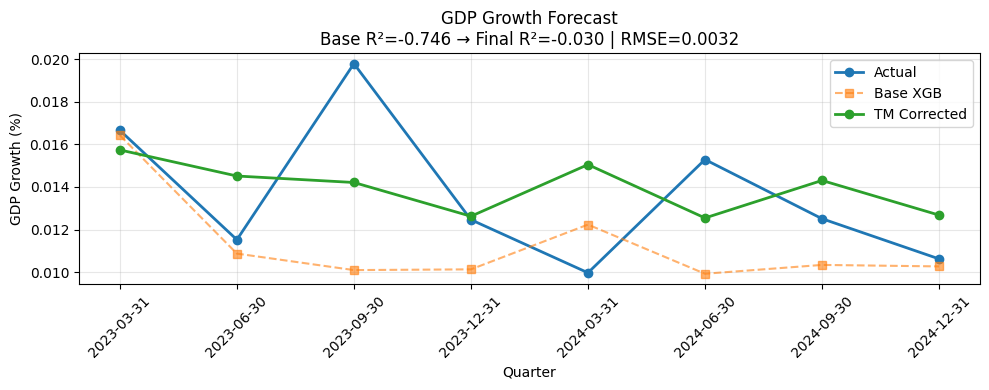

In [ ]:
results, rmse, mae, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True,  importance_strategy = 'shap',
    tune=False, feature_selection=True, shap_binarise=False
)
#best = {"number_of_clauses": 77, "T": 37, "s": 3.19}


XGB + Tsetlin Residual Corrector
Base R²: -1.7544  →  Final R²: 0.1923
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                         MAE: 0.00258
                                        RMSE: 0.00283
                                    MAPE (%): 19.59
                                          R²: 0.1923
Inference time: 265.046 ms


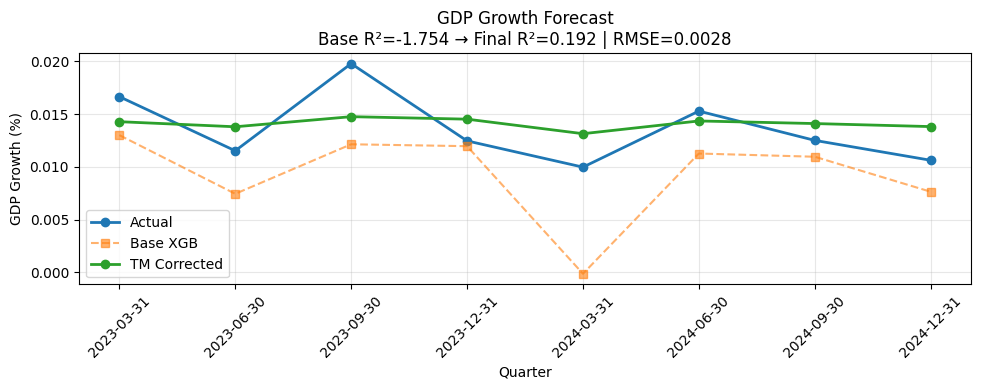

In [ ]:
results, rmse, mae, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True,  importance_strategy = 'shap',
    tune=False, feature_selection=True, shap_binarise=False
)
#{'number_of_clauses': 74, 'T': 24, 's': 3.1646051210763435}

### Tsetlin with shap

  Computing SHAP importance for binarisation...

  SHAP-guided bins — min:5 max:15 mean:9.8

XGB + Tsetlin Residual Corrector
Base R²: -0.7462  →  Final R²: -0.1898
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.02         0.01
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                         MAE: 0.00264
                                        RMSE: 0.00343
                                    MAPE (%): 20.05
                                          R²: -0

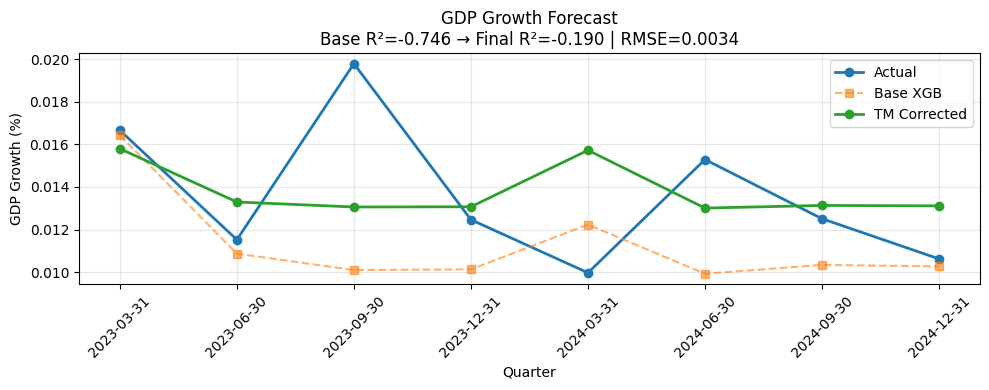

In [ ]:
results, rmse, mae, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True,  importance_strategy = 'shap',
    tune=False, feature_selection=True, shap_binarise=True
)
#{'number_of_clauses': 190, 'T': 99, 's': 4.750298104270476}

  Computing SHAP importance for binarisation...

  SHAP-guided bins — min:5 max:15 mean:8.9

XGB + Tsetlin Residual Corrector
Base R²: -1.7544  →  Final R²: -0.2966
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.02         0.00
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.02         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.02         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
                                         MAE: 0.00330
                                        RMSE: 0.00359
                                    MAPE (%): 26.85
                                          R²: -0

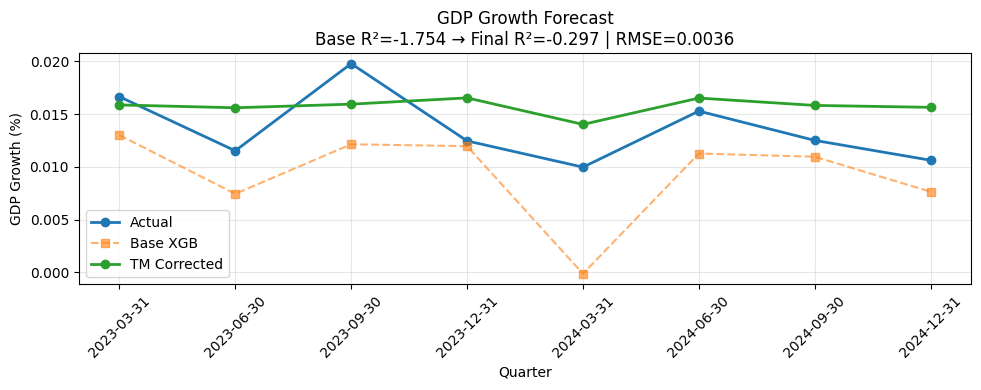

In [ ]:
results, rmse, mae, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True,  importance_strategy = 'shap',
    tune=False, feature_selection=True, shap_binarise=True
)
#{"number_of_clauses": 200, "T": 50, "s": 2.5}

### regime based Tsetlin with shap


[Regime Detection]
  HMM regimes — Expansion: 1q | Stress/Recession: 123q
  Features used: ['gdp_lag1']

[Base Model]

[Optuna Tuning — shared TM params]


  0%|          | 0/30 [00:00<?, ?it/s]

Best params: {'number_of_clauses': 157, 'T': 83, 's': 2.8207002793611666}  RMSE: 0.0238

[Regime-Conditional TM Training]
  Regime 0 (Expansion): 1 quarters
  → Too few samples, skipping dedicated TM (will use fallback)
  Regime 1 (Stress/Recession): 123 quarters

  SHAP-guided bins — min:5 max:20 mean:8.4



  SHAP-guided bins — min:5 max:20 mean:11.2

[Test Prediction — regime-conditional]



  SHAP-guided bins — min:5 max:20 mean:11.2


...


  SHAP-guided bins — min:5 max:20 mean:11.2



  SHAP-guided bins — min:5 max:20 mean:11.2



  SHAP-guided bins — min:5 max:20 mean:11.2



  SHAP-guided bins — min:5 max:20 mean:11.2



  SHAP-guided bins — min:5 max:20 mean:11.2

  SHAP-guided bins — min:5 max:20 mean:11.2

Regime-Conditional Bayes + Tsetlin  [SHAP-bins + Regime-TM]
Base R²: -0.3494  →  Final R²: -0.5500
Date              Actual  Predicted    Error   Regime
-----------------------------------------------------------------
2023-03-31          0.02       0.02     0.00   Expand
2023-06-30          0.01       0.02     0.01   Expand
2023-09-30          0.02       0.02     0.00   Expand
2023-12-31          0.01       0.01     0.00   Expand
2024-03-31          0.01       0.02     0.01   Expand
2024-06-30          0.02       0.01     0.00   Expand
2024-09-30          0.01       0.01     0.00   Expand
2024-12-31          0.01       0.01     0.00   Expand
-----------------------------------------------------------------
                                         MAE: 0.00339
                                        RMSE: 0.00392
                                    MAPE (%): 27.26
                                

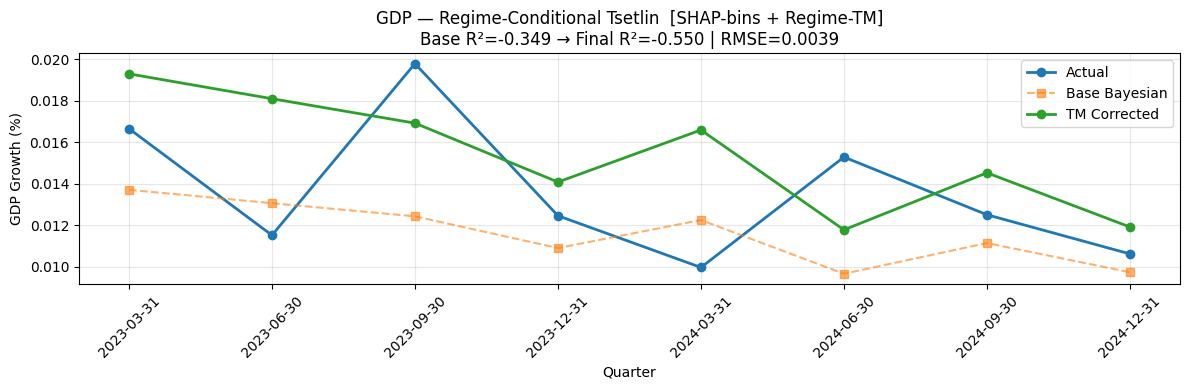

In [ ]:
results, rmse, mae, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True,  importance_strategy = 'shap',
    tune=True, feature_selection=True, shap_binarise=True
)
# {'number_of_clauses': 157, 'T': 83, 's': 2.8207002793611666}


[Regime Detection]
  HMM regimes — Expansion: 1q | Stress/Recession: 123q
  Features used: ['gdp_lag1']

[Base Model]



[Regime-Conditional TM Training]
  Regime 0 (Expansion): 1 quarters
  → Too few samples, skipping dedicated TM (will use fallback)
  Regime 1 (Stress/Recession): 123 quarters

  SHAP-guided bins — min:5 max:20 mean:12.4



  SHAP-guided bins — min:5 max:20 mean:12.3

[Test Prediction — regime-conditional]



  SHAP-guided bins — min:5 max:20 mean:12.3



  SHAP-guided bins — min:5 max:20 mean:12.3


...


  SHAP-guided bins — min:5 max:20 mean:12.3



  SHAP-guided bins — min:5 max:20 mean:12.3



  SHAP-guided bins — min:5 max:20 mean:12.3



  SHAP-guided bins — min:5 max:20 mean:12.3



  SHAP-guided bins — min:5 max:20 mean:12.3

  SHAP-guided bins — min:5 max:20 mean:12.2

Regime-Conditional Bayes + Tsetlin  [SHAP-bins + Regime-TM]
Base R²: -16.3524  →  Final R²: -1.5025
Date              Actual  Predicted    Error   Regime
-----------------------------------------------------------------
2023-03-31          0.02       0.01     0.01   Expand
2023-06-30          0.01       0.01     0.00   Expand
2023-09-30          0.02       0.01     0.01   Expand
2023-12-31          0.01       0.01     0.00   Expand
2024-03-31          0.01       0.01     0.00   Expand
2024-06-30          0.02       0.02     0.00   Expand
2024-09-30          0.01       0.01     0.00   Expand
2024-12-31          0.01       0.01     0.00   Expand
-----------------------------------------------------------------
                                         MAE: 0.00305
                                        RMSE: 0.00498
                                    MAPE (%): 19.36
                               

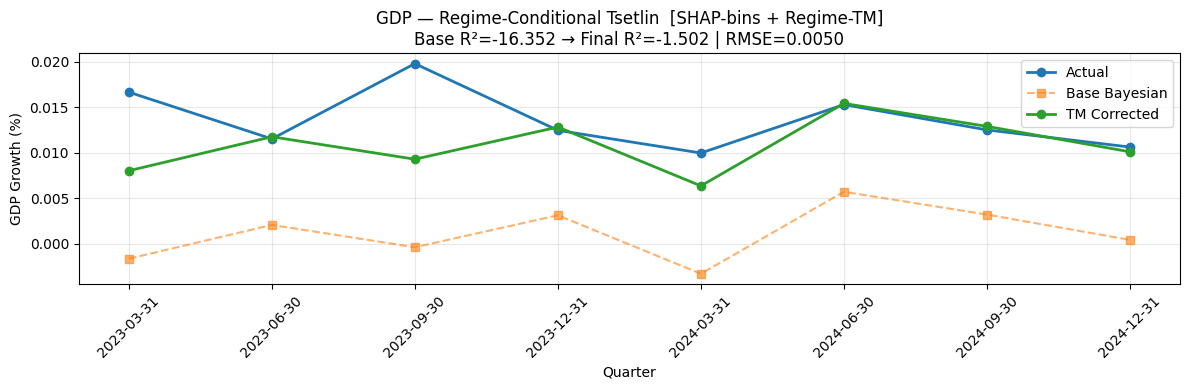

In [ ]:
results, rmse, mae, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True,  importance_strategy = 'shap',
    tune=False, feature_selection=True, shap_binarise=True
)
# {"number_of_clauses": 200, "T": 50, "s": 2.5}

### KNN

Total: 132 | Train: 124 | Test: 8 | Features: 12

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.01
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.01
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00522
                                         MAE:       0.00391
                                    MAPE (%):        26.02
                                          R²:      -1.7475
Inference time: 26.067 ms


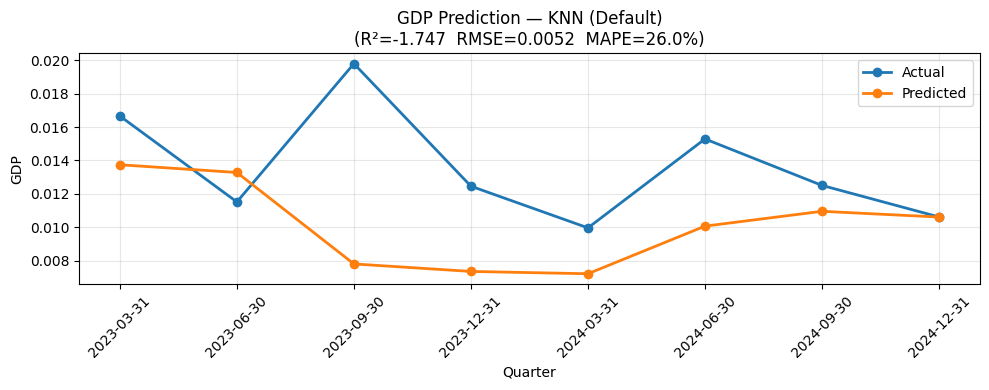

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_standard, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime= GDP_prediction(
    df,
    use_macro=False,
    model='KNN',
    use_scaling=True,
    importance_strategy = 'alime',
    feature_selection=True,
    tune=False
)

Total: 132 | Train: 124 | Test: 8 | Features: 56

Tuning KNN with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.2057
  Best params: {'model__weights': 'uniform', 'model__n_neighbors': 10, 'model__metric': 'manhattan', 'model__leaf_size': 20}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.01
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00516
                                         MAE:       0.00409
  

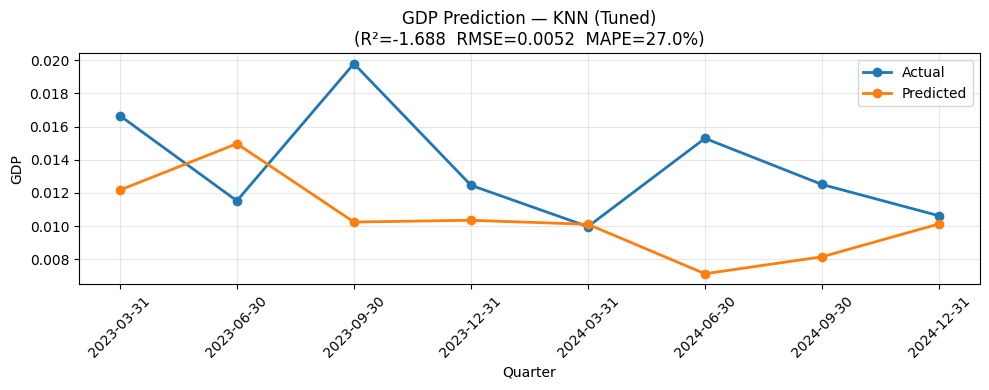

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_standard, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='KNN',
    use_scaling=True,
    importance_strategy = 'alime',
    feature_selection=True,
    tune=True
)

### Bayes

Total: 132 | Train: 124 | Test: 8 | Features: 12

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.6962
  Best params: {'model__max_iter': 300, 'model__lambda_2': 1e-07, 'model__lambda_1': 1e-05, 'model__alpha_2': 1e-06, 'model__alpha_1': 1e-07}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.01
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00457
                                         MA

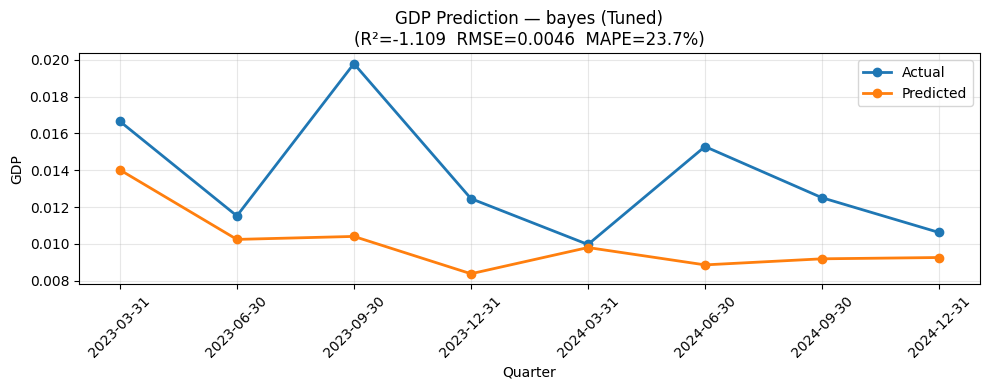

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_standard, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime= GDP_prediction(
    df,
    use_macro=False,
    model='bayes',
    use_scaling=True,
    importance_strategy = 'alime',
    feature_selection=True,
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 56

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.1899
  Best params: {'model__max_iter': 1000, 'model__lambda_2': 1e-05, 'model__lambda_1': 1e-05, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-06}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.02         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.02         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00306
                                         M

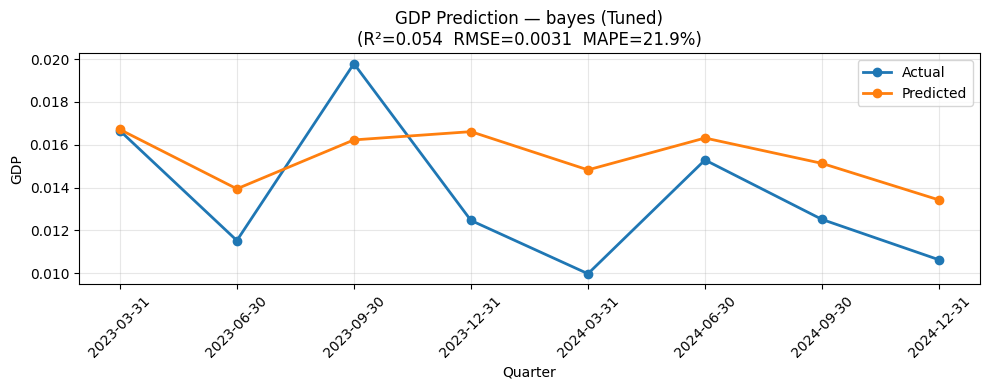

  0%|          | 0/124 [00:00<?, ?it/s]

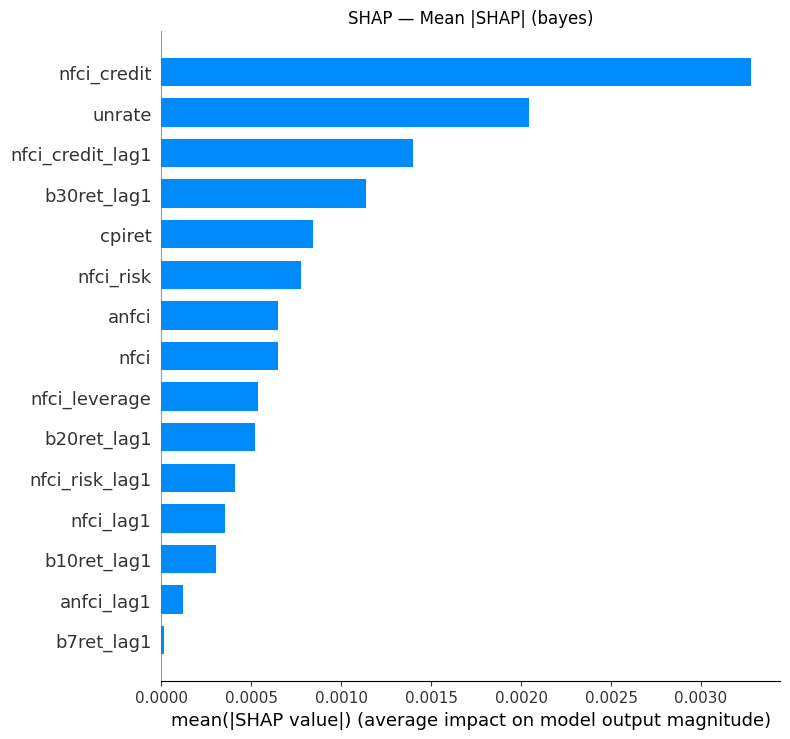

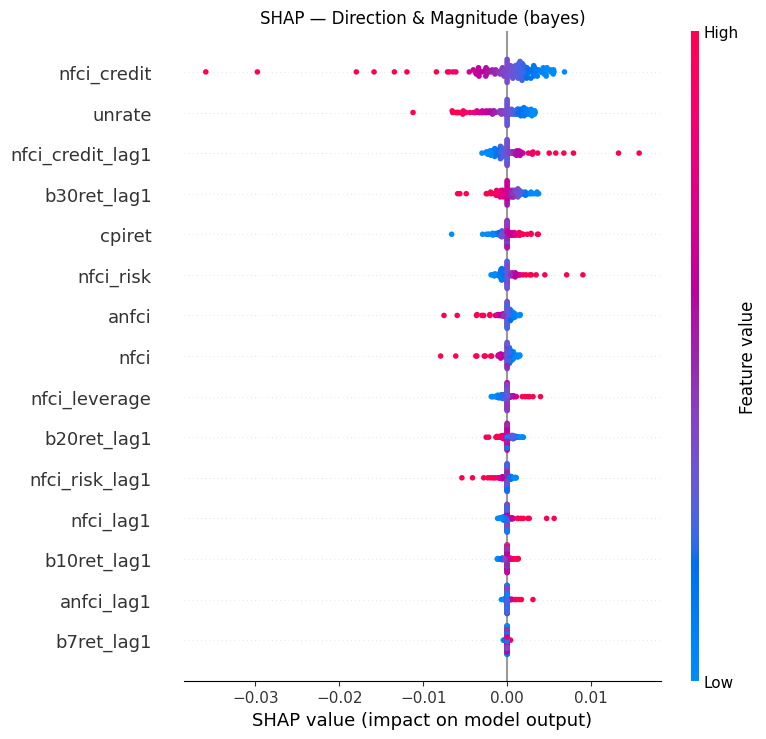

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_standard, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    importance_strategy = 'shap',
    feature_selection=True,
    tune=True
)

### SVR

Total: 132 | Train: 124 | Test: 8 | Features: 12

Tuning SVR with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.2684
  Best params: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__epsilon': 0.01, 'model__C': 50.0}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.00         0.01
2023-09-30              0.02        -0.01         0.03
2023-12-31              0.01        -0.04         0.05
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
                                        RMSE:      0.02265
                                         MAE:       0.01398
                     

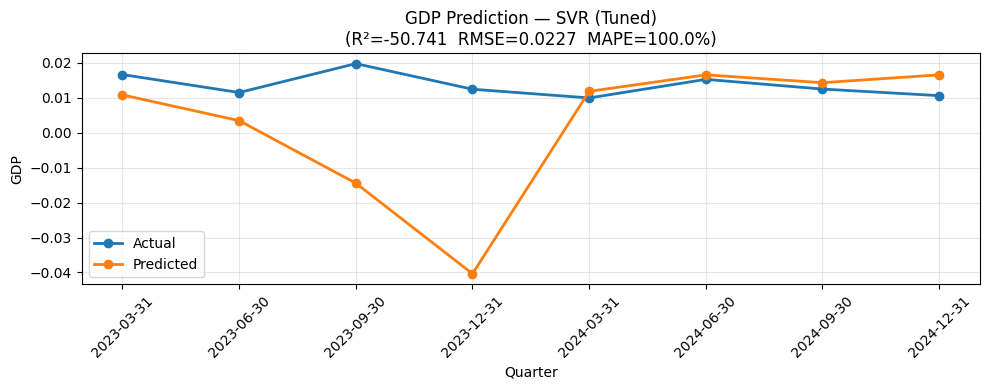

In [ ]:
results, rmse, mae, mape, r2, svr_fi_standard, svr_fi_shap, svr_fi_perm, svr_fi_lime= GDP_prediction(
    df,
    use_macro=False,
    model='SVR',
    use_scaling=True,
    importance_strategy = 'none',
    feature_selection=False,
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 56

Tuning SVR with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.2859
  Best params: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__epsilon': 0.01, 'model__C': 50.0}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.02         0.01
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.01
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00530
                                         MAE:       0.00500
                     

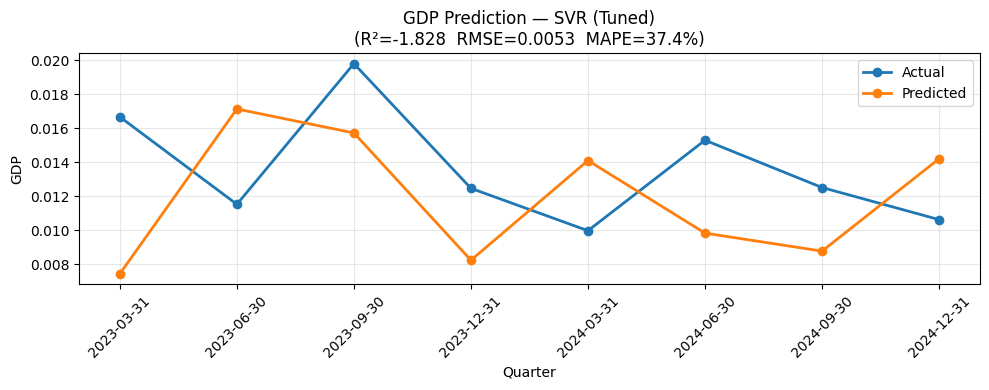

In [ ]:
results, rmse, mae, mape, r2, svr_fi_standard, svr_fi_shap, svr_fi_perm, svr_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='SVR',
    use_scaling=True,
    importance_strategy = 'alime',
    feature_selection=True,
    tune=True
)

### Catboost

Total: 132 | Train: 124 | Test: 8 | Features: 12

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.3255
  Best params: {'model__subsample': 0.6, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 10.0, 'model__iterations': 300, 'model__depth': 5}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.01
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00514
                                      

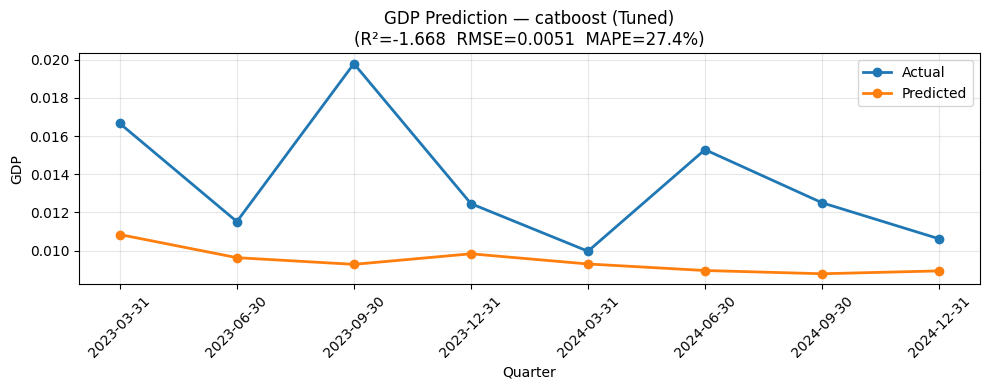

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_standard, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime= GDP_prediction(
    df,
    use_macro=False,
    model='catboost',
    use_scaling=True,
    importance_strategy = 'lime',
    feature_selection=True,
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 56

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.2154
  Best params: {'model__subsample': 0.6, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 10.0, 'model__iterations': 300, 'model__depth': 4}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00324
                                      

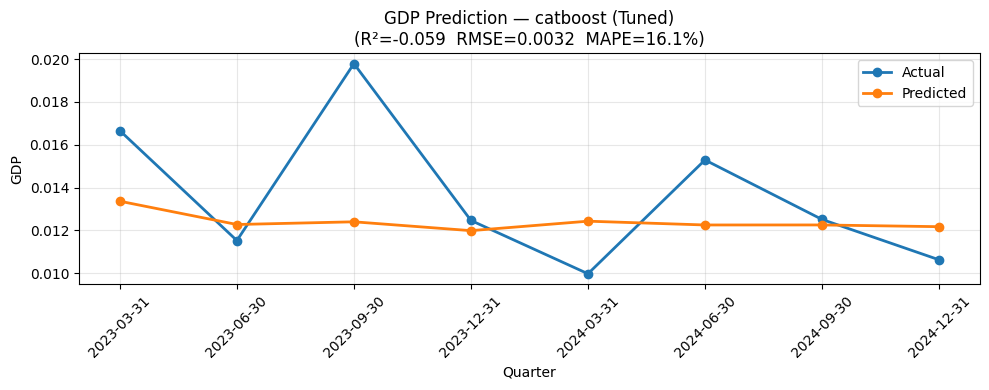

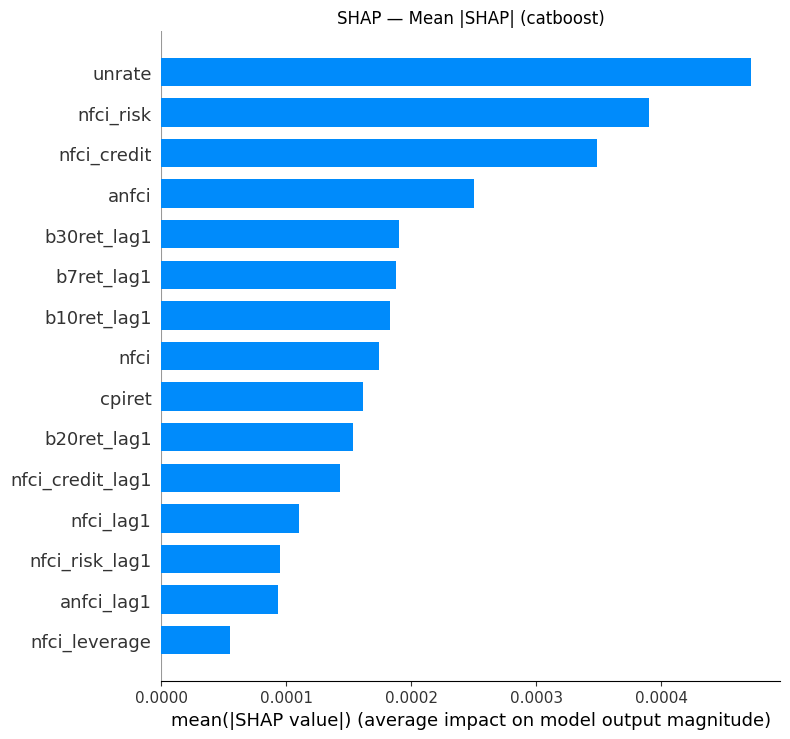

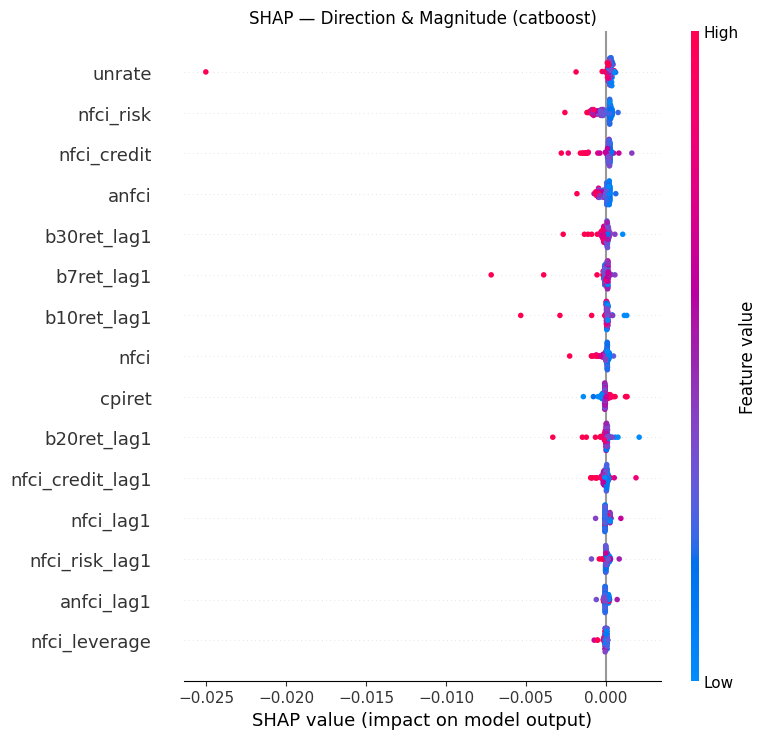

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_standard, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='catboost',
    use_scaling=True,
    importance_strategy = 'shap',
    feature_selection=True,
    tune=True
)

### GB

Total: 132 | Train: 124 | Test: 8 | Features: 12

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.5890
  Best params: {'model__subsample': 0.6, 'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 2, 'model__learning_rate': 0.01}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.01
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:      0.00601
                                    

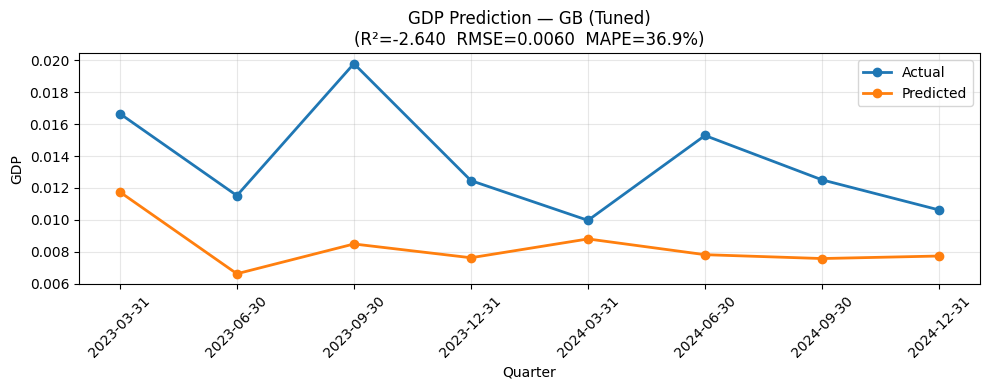

In [ ]:
results, rmse, mae, mape, r2, GB_fi_standard, GB_fi_shap, GB_fi_perm, GB_fi_lime= GDP_prediction(
    df,
    use_macro=False,
    model='GB',
    use_scaling=True,
    importance_strategy = 'alime',
    feature_selection=True,
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 56

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.3154
  Best params: {'model__subsample': 0.6, 'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 2, 'model__learning_rate': 0.01}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.02         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
                                        RMSE:      0.00431
                                    

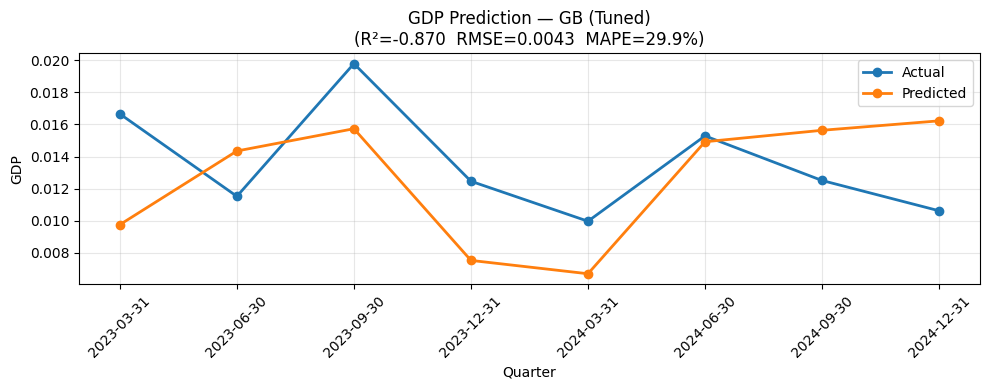

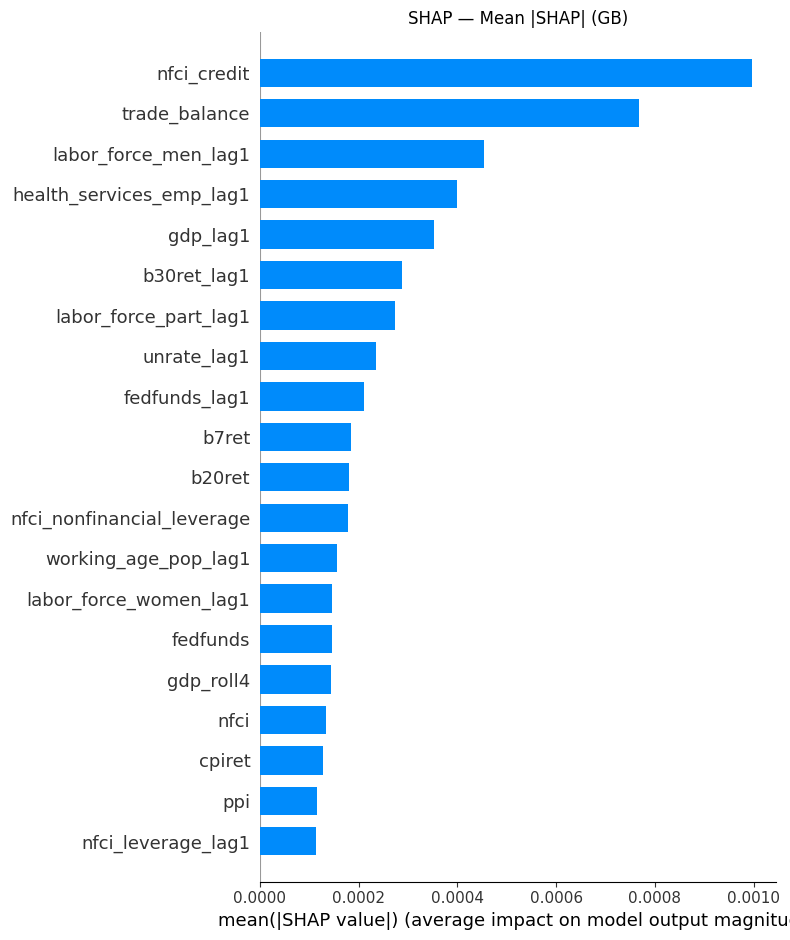

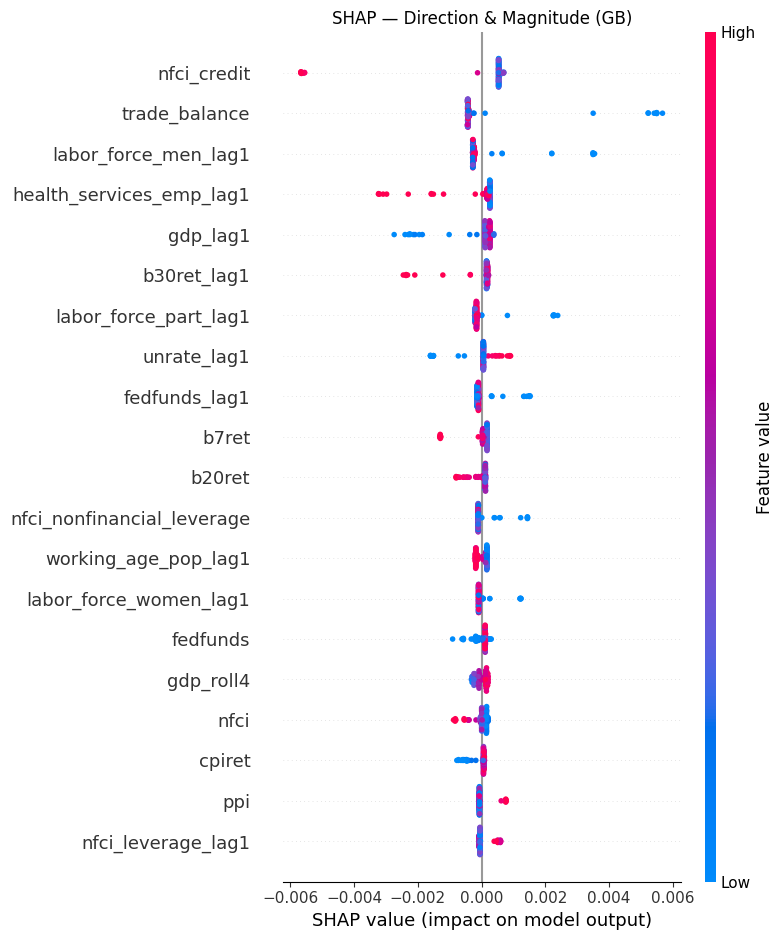

In [ ]:
results, rmse, mae, mape, r2, GB_fi_standard, GB_fi_shap, GB_fi_perm, GB_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='GB',
    use_scaling=True,
    importance_strategy = 'shap',
    feature_selection=False,
    tune=True
)

### XGB

Total: 132 | Train: 124 | Test: 8 | Features: 12

Tuning XGB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.2382
  Best params: {'model__subsample': 0.7, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.02         0.00
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.02         0.00
2024-03-31              0.01         0.02         0.01
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.02         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
           

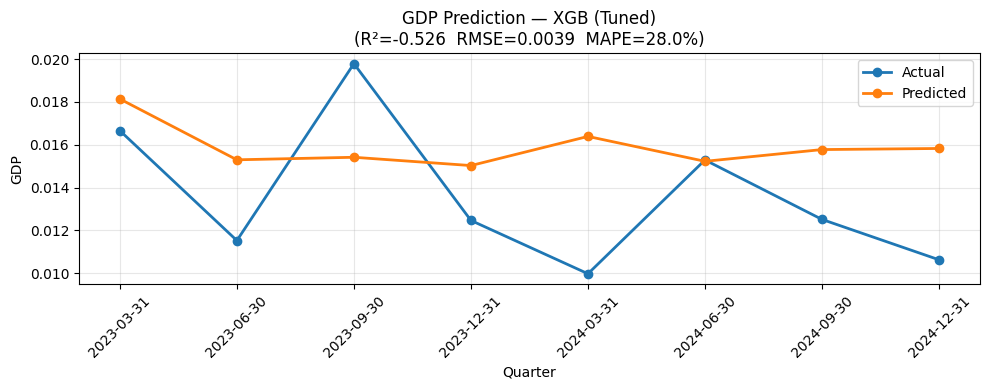

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_standard, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime= GDP_prediction(
    df,
    use_macro=False,
    model='XGB',
    use_scaling=True,
    importance_strategy = 'lime',
    feature_selection=True,
    tune=True,


)

Total: 132 | Train: 124 | Test: 8 | Features: 56

Tuning XGB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.2365
  Best params: {'model__subsample': 0.6, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.02         0.01
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
           

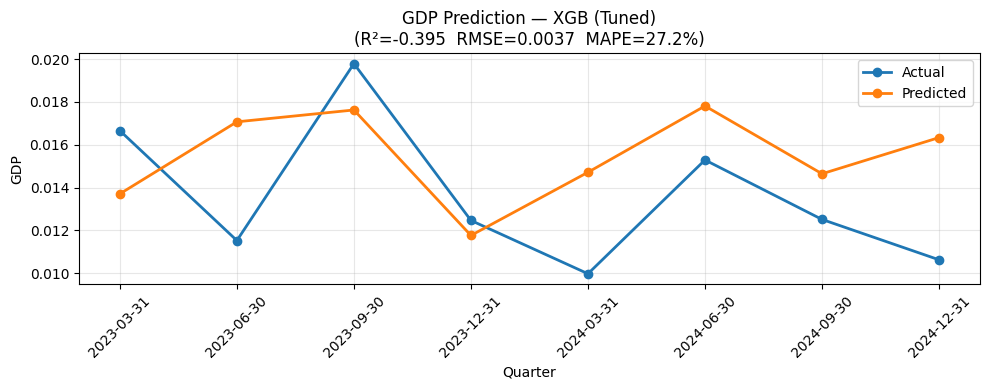

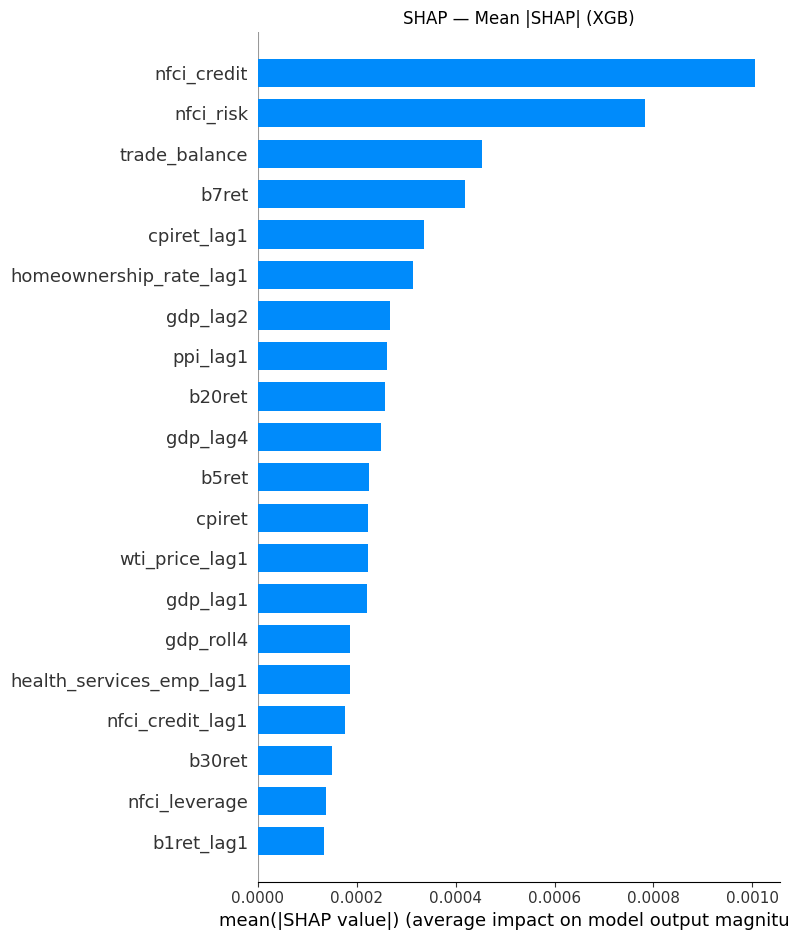

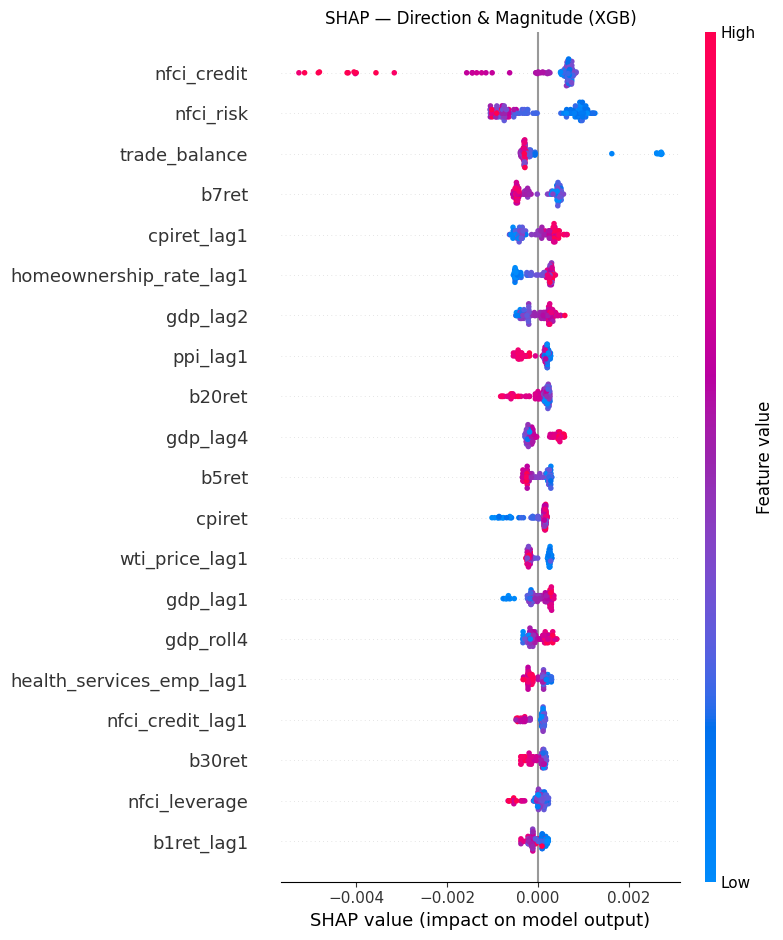

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_standard, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    importance_strategy = 'shap',
    feature_selection=False,
    tune=True,


)

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMA — Best order AIC: -678.16
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:       0.0041
                                         MAE:        0.0030
                                    MAPE (%):        18.46
                                          R²:      -0.7000
Inference time: 2.454 ms


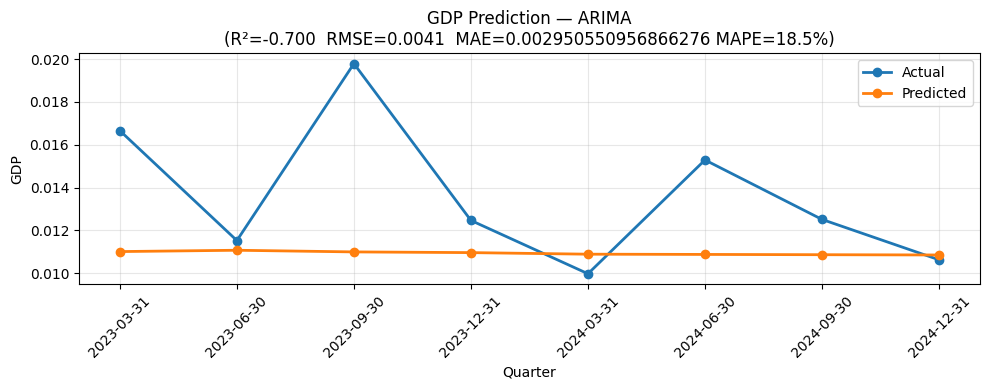

In [ ]:
results, rmse, mae, mape, r2= GDP_prediction(
    df,
    use_macro=False,
    model='arima',
    use_scaling=True,
    feature_selection=True, importance_strategy = 'lime',
    tune=True
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best order AIC: -745.17
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01        -0.01         0.02
2024-06-30              0.02        -0.02         0.03
2024-09-30              0.01        -0.02         0.04
2024-12-31              0.01        -0.02         0.03
-----------------------------------------------------------------
                                        RMSE:       0.0236
                                         MAE:        0.0189
                                    MAPE (%):       152.01
                                          R²:     -54.9936
Inference time: 3.787 ms


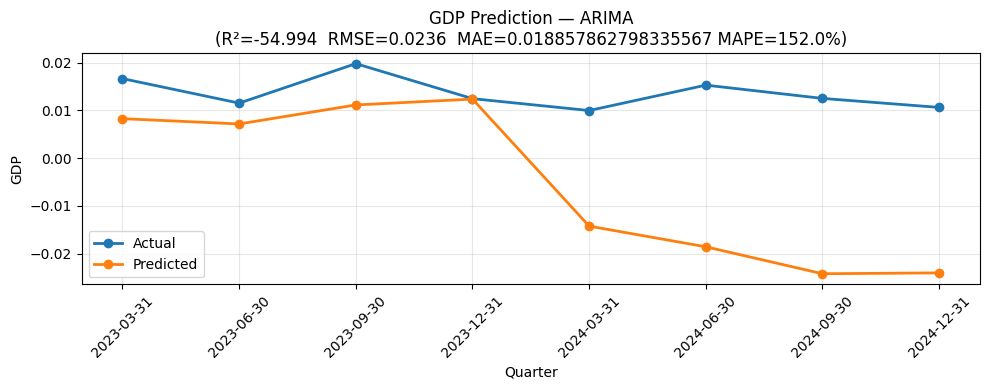

In [ ]:
results, rmse, mae, mape, r2= GDP_prediction(
    df,
    use_macro=True,
    model='arima',
    use_scaling=True,
    feature_selection=True, importance_strategy = 'lime',
    tune=True
)

### save importance results

In [ ]:
importance_results = {
    'XGB':      xgb_fi_shap,
    'GB':       GB_fi_shap,
    'bayes':    bayes_fi_shap,
    'catboost': catboost_fi_shap,
}

for model_name, df in importance_results.items():
    df.to_csv(f"/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/{model_name}_shap_importance_GDP.csv", index=False)